In [1]:
import pandas as pd
import numpy as np

# Cố định random seed theo yêu cầu tái lập
np.random.seed(42)

# Khai báo tên cột dựa theo file adult.names
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
           'marital-status', 'occupation', 'relationship', 'race', 'sex', 
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# Đọc file dữ liệu
df = pd.read_csv('../data/adult.data', names=columns, skipinitialspace=True)

# Hiển thị 5 dòng đầu tiên
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Số lượng dấu '?' trong các cột:
workclass         1836
occupation        1843
native-country     583
dtype: int64


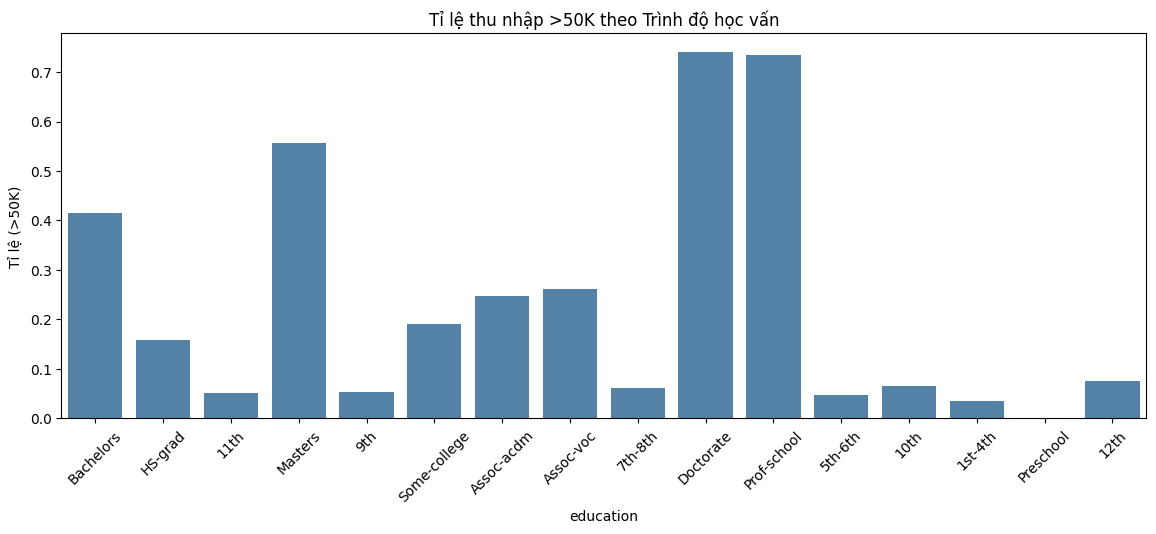

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kiểm tra giá trị thiếu (ẩn dưới dạng dấu '?')
print("Số lượng dấu '?' trong các cột:")
missing_data = (df == '?').sum()
print(missing_data[missing_data > 0])

# 2. Tạo cột income_binary (0 và 1) để tính tỉ lệ
df['income_binary'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 3. Vẽ biểu đồ tỉ lệ thu nhập >50K theo Học vấn
plt.figure(figsize=(14, 5))
sns.barplot(data=df, x='education', y='income_binary', errorbar=None, color='steelblue')
plt.xticks(rotation=45)
plt.title('Tỉ lệ thu nhập >50K theo Trình độ học vấn')
plt.ylabel('Tỉ lệ (>50K)')
plt.show()

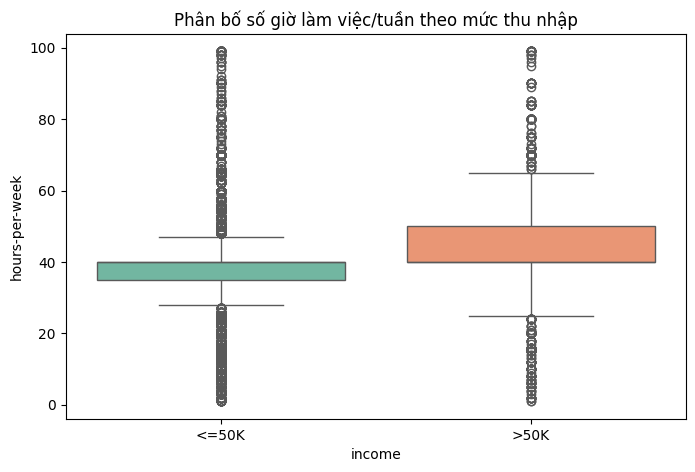

Kích thước dữ liệu sau khi làm sạch: (30162, 16)


In [3]:
# 1. Vẽ biểu đồ phân bố số giờ làm việc/tuần theo mức thu nhập
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week', hue='income', palette='Set2')
plt.title('Phân bố số giờ làm việc/tuần theo mức thu nhập')
plt.show()

# 2. Xử lý giá trị thiếu '?'
# Thay thế '?' bằng NaN (Not a Number), sau đó xóa các dòng chứa NaN để làm sạch
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Kích thước dữ liệu sau khi làm sạch: {df.shape}")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Tách Đặc trưng (X) và Nhãn (y)
X = df.drop(['income', 'income_binary'], axis=1)
y = df['income_binary']

# 2. Chia tập Train/Test (dùng stratify để giữ nguyên tỉ lệ nhãn)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Phân loại các cột dạng số và dạng phân loại (categorical)
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# 4. Xây dựng bộ tiền xử lý (Preprocessor)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")

Kích thước X_train: (24129, 14)
Kích thước X_test: (6033, 14)


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo hội tụ (convergence warnings) cho gọn

# 1. Khởi tạo các mô hình (cố định seed)
models = {
    'Majority Class': DummyClassifier(strategy='prior'),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Linear SVC': LinearSVC(random_state=42, max_iter=2000)
}

# 2. Cấu hình Stratified 5-Fold CV và Metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'ROC-AUC': 'roc_auc', 'PR-AUC': 'average_precision', 'F1': 'f1'}

# 3. Huấn luyện và Đánh giá từng mô hình bằng Pipeline
results = {}
for name, model in models.items():
    # Tạo Pipeline chuẩn: Tiền xử lý -> Mô hình
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    # Chạy Cross-Validation
    cv_results = cross_validate(clf, X_train, y_train, cv=cv, scoring=scoring)
    
    # Lưu kết quả định dạng mean ± std
    results[name] = {
        'ROC-AUC': f"{cv_results['test_ROC-AUC'].mean():.3f} ± {cv_results['test_ROC-AUC'].std():.3f}",
        'PR-AUC': f"{cv_results['test_PR-AUC'].mean():.3f} ± {cv_results['test_PR-AUC'].std():.3f}",
        'F1': f"{cv_results['test_F1'].mean():.3f} ± {cv_results['test_F1'].std():.3f}"
    }

# 4. Hiển thị bảng kết quả
results_df = pd.DataFrame(results).T
print("Kết quả đánh giá bằng 5-Fold CV trên tập Train:")
display(results_df)

Kết quả đánh giá bằng 5-Fold CV trên tập Train:


,ROC-AUC,PR-AUC,F1
Majority Class,0.500 ± 0.000,0.249 ± 0.000,0.000 ± 0.000
Logistic Regression,0.906 ± 0.003,0.771 ± 0.008,0.663 ± 0.005
Linear SVC,0.905 ± 0.003,0.771 ± 0.009,0.661 ± 0.006


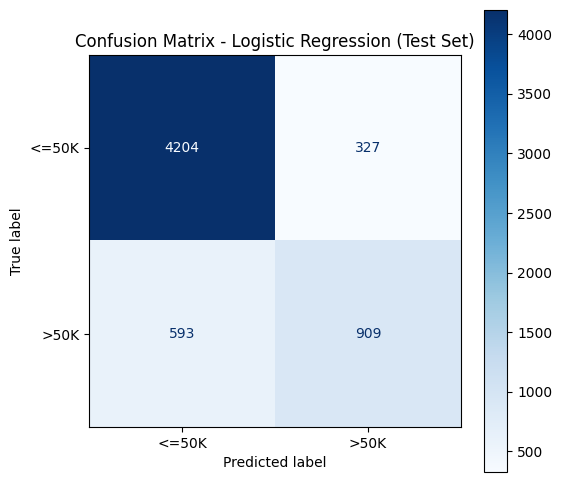

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4531
           1       0.74      0.61      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.77      0.78      6033
weighted avg       0.84      0.85      0.84      6033



In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Huấn luyện lại mô hình Logistic Regression trên toàn bộ tập Train
best_model = Pipeline(steps=[('preprocessor', preprocessor), 
                             ('classifier', LogisticRegression(random_state=42, max_iter=1000))])
best_model.fit(X_train, y_train)

# 2. Dự đoán trên tập Test
y_pred = best_model.predict(X_test)

# 3. Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix - Logistic Regression (Test Set)')
plt.show()

# 4. In báo cáo phân loại chi tiết (bao gồm F1-score)
print(classification_report(y_test, y_pred))

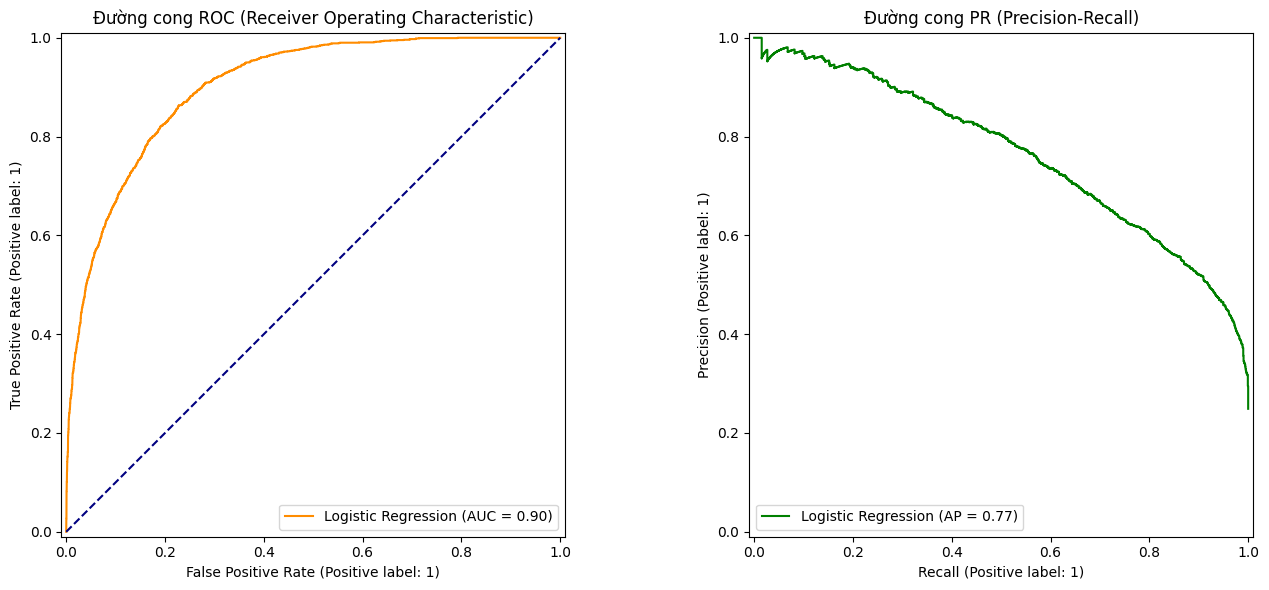

In [7]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Vẽ đường cong ROC
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax1, name='Logistic Regression', color='darkorange')
ax1.set_title('Đường cong ROC (Receiver Operating Characteristic)')
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--') # Đường random guess

# 2. Vẽ đường cong Precision-Recall (PR)
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax2, name='Logistic Regression', color='green')
ax2.set_title('Đường cong PR (Precision-Recall)')

plt.tight_layout()
plt.show()

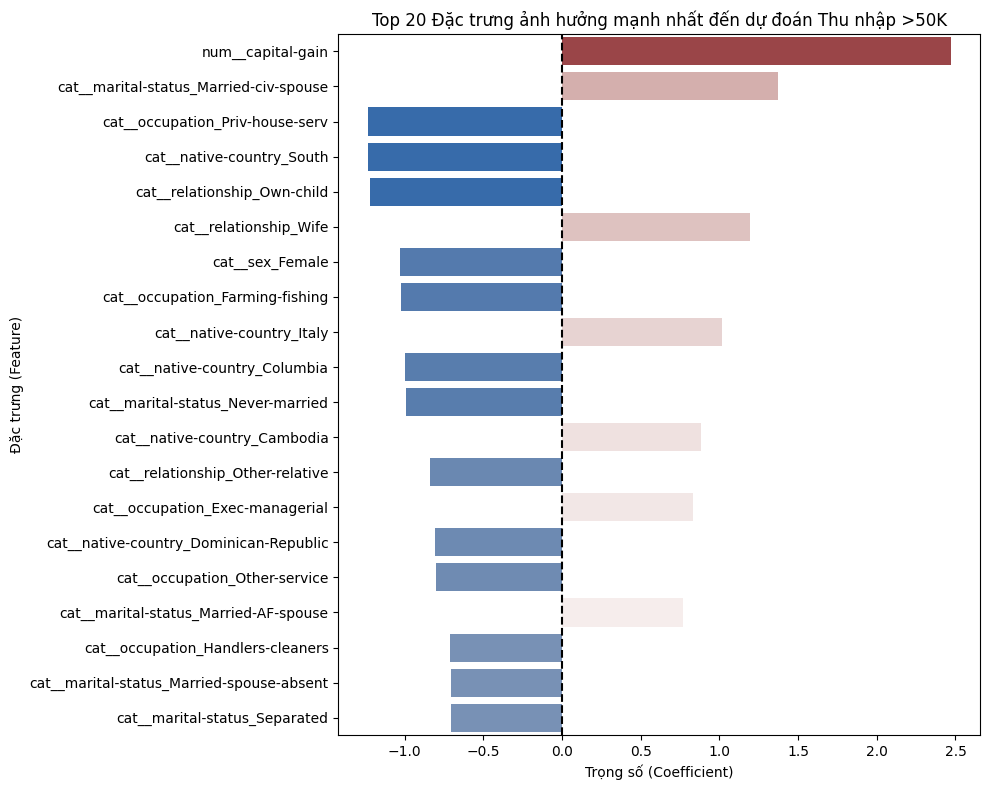

In [8]:
# Lấy mô hình và bộ tiền xử lý từ Pipeline
classifier = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

# Lấy tên các đặc trưng sau khi tiền xử lý (One-hot encoding)
feature_names = preprocessor.get_feature_names_out()

# Lấy hệ số (coefficients) của mô hình
coefficients = classifier.coef_[0]

# Tạo DataFrame để dễ thao tác
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Lấy top 20 đặc trưng có ảnh hưởng mạnh nhất (dựa trên giá trị tuyệt đối)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(data=top_coef_df, x='Coefficient', y='Feature', hue='Coefficient', palette='vlag', legend=False)
plt.title('Top 20 Đặc trưng ảnh hưởng mạnh nhất đến dự đoán Thu nhập >50K')
plt.xlabel('Trọng số (Coefficient)')
plt.ylabel('Đặc trưng (Feature)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [9]:
# Thử nghiệm Ablation: So sánh L1 và L2 Regularization trên Logistic Regression
from sklearn.model_selection import cross_validate
import pandas as pd

# Khởi tạo 2 mô hình với L1 và L2
logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
logreg_l2 = LogisticRegression(penalty='l2', solver='lbfgs', random_state=42, max_iter=1000)

# Đưa vào Pipeline
pipe_l1 = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', logreg_l1)])
pipe_l2 = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', logreg_l2)])

# Đánh giá bằng 5-Fold CV đã cấu hình ở bước trước
models_ablation = {'Logistic Regression (L1)': pipe_l1, 'Logistic Regression (L2)': pipe_l2}
results_ablation = {}

for name, model in models_ablation.items():
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    results_ablation[name] = {
        'ROC-AUC': f"{cv_res['test_ROC-AUC'].mean():.3f} ± {cv_res['test_ROC-AUC'].std():.3f}",
        'PR-AUC': f"{cv_res['test_PR-AUC'].mean():.3f} ± {cv_res['test_PR-AUC'].std():.3f}",
        'F1': f"{cv_res['test_F1'].mean():.3f} ± {cv_res['test_F1'].std():.3f}"
    }

# Hiển thị kết quả
ablation_df = pd.DataFrame(results_ablation).T
print("Kết quả Ablation Study: L1 vs L2 Regularization")
display(ablation_df)

Kết quả Ablation Study: L1 vs L2 Regularization


,ROC-AUC,PR-AUC,F1
Logistic Regression (L1),0.905 ± 0.003,0.772 ± 0.008,0.663 ± 0.006
Logistic Regression (L2),0.906 ± 0.003,0.771 ± 0.008,0.663 ± 0.005


In [10]:
# Lấy lại dữ liệu X_test ban đầu (chưa qua tiền xử lý) để trích xuất cột giới tính
X_test_original = df.loc[X_test.index]

# Lấy nhãn dự đoán từ mô hình Logistic Regression tốt nhất
y_pred = best_model.predict(X_test)

# 1. Đánh giá cho nhóm Nam (Male)
mask_male = X_test_original['sex'] == 'Male'
print("--- Báo cáo phân loại cho nhóm NAM (Male) ---")
print(classification_report(y_test[mask_male], y_pred[mask_male]))

# 2. Đánh giá cho nhóm Nữ (Female)
mask_female = X_test_original['sex'] == 'Female'
print("--- Báo cáo phân loại cho nhóm NỮ (Female) ---")
print(classification_report(y_test[mask_female], y_pred[mask_female]))

--- Báo cáo phân loại cho nhóm NAM (Male) ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      2798
           1       0.74      0.62      0.67      1267

    accuracy                           0.81      4065
   macro avg       0.79      0.76      0.77      4065
weighted avg       0.81      0.81      0.81      4065

--- Báo cáo phân loại cho nhóm NỮ (Female) ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1733
           1       0.72      0.54      0.62       235

    accuracy                           0.92      1968
   macro avg       0.83      0.76      0.79      1968
weighted avg       0.91      0.92      0.92      1968



In [11]:
from sklearn.neural_network import MLPClassifier

# 1. Khởi tạo mạng nơ-ron (MLP) với 2 lớp ẩn nhỏ (64 và 32 nơ-ron)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True)

# 2. Đưa vào Pipeline
pipe_mlp = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', mlp_model)])

# 3. Đánh giá bằng 5-Fold CV (Giống các mô hình trước)
print("Đang huấn luyện mô hình Deep Learning (MLP)... Vui lòng đợi khoảng 1-2 phút nhé!")
cv_mlp = cross_validate(pipe_mlp, X_train, y_train, cv=cv, scoring=scoring)

# 4. In kết quả định dạng mean ± std
print("\nKết quả của Optional DL (MLP):")
print(f"ROC-AUC: {cv_mlp['test_ROC-AUC'].mean():.3f} ± {cv_mlp['test_ROC-AUC'].std():.3f}")
print(f"PR-AUC:  {cv_mlp['test_PR-AUC'].mean():.3f} ± {cv_mlp['test_PR-AUC'].std():.3f}")
print(f"F1:      {cv_mlp['test_F1'].mean():.3f} ± {cv_mlp['test_F1'].std():.3f}")

Đang huấn luyện mô hình Deep Learning (MLP)... Vui lòng đợi khoảng 1-2 phút nhé!

Kết quả của Optional DL (MLP):
ROC-AUC: 0.911 ± 0.004
PR-AUC:  0.785 ± 0.007
F1:      0.689 ± 0.011


In [12]:
import joblib
import os

# 1. Tạo thư mục 'models' trong src để chứa mô hình (nếu chưa có)
os.makedirs('../src/models', exist_ok=True)

# 2. Lưu lại Pipeline (bao gồm cả bước tiền xử lý và mô hình Logistic Regression)
joblib.dump(best_model, '../src/models/income_classifier.pkl')

print("Đã lưu mô hình thành công vào thư mục src/models!")

Đã lưu mô hình thành công vào thư mục src/models!
